In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\User\Desktop\Project python 2, 2026\netflix_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [4]:
df.describe()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,29.874000,12.323340,1.999140,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,13.528733,17.051104,3.309109,0.818238,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,18.000000,1.000000,7.990000,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,7.990000,1.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,41.000000,30.000000,12.990000,2.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,53.000000,45.000000,15.990000,3.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,64.000000,59.000000,15.990000,3.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50000 non-null  object 
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   country                    50000 non-null  object 
 4   account_age_months         50000 non-null  int64  
 5   subscription_type          50000 non-null  object 
 6   monthly_fee                50000 non-null  float64
 7   payment_method             50000 non-null  object 
 8   primary_device             50000 non-null  object 
 9   devices_used               50000 non-null  int64  
 10  favorite_genre             50000 non-null  object 
 11  avg_watch_time_minutes     50000 non-null  int64  
 12  watch_sessions_per_week    50000 non-null  int64  
 13  binge_watch_sessions       50000 non-null  int

In [ ]:
print(df.to_string())

In [7]:
print("Overall Churn Rate:")
print(df['churned'].value_counts(normalize=True) * 100)
behavioural_col = ['avg_watch_time_minutes','watch_sessions_per_week',
                   'days_since_last_login','completion_rate','content_interactions']
print("\nAverage Behavioral Metrics by Churn Status:")
print(df.groupby('churned')[behavioural_col].mean())

Overall Churn Rate:
churned
No     80.072
Yes    19.928
Name: proportion, dtype: float64

Average Behavioral Metrics by Churn Status:
         avg_watch_time_minutes  watch_sessions_per_week  \
churned                                                    
No                   155.156284                 9.996503   
Yes                  154.103673                 9.948414   

         days_since_last_login  completion_rate  content_interactions  
churned                                                                
No                   29.406609        64.551953             24.354881  
Yes                  29.426234        64.458952             24.111501  


In [ ]:
print("Overall Churn Rate:")
print(df['churned'].value_counts(normalize=True) * 100)
behavioural_col = ['avg_watch_time_minutes','watch_sessions_per_week',
                   'days_since_last_login','completion_rate','content_interactions']
print("\nAverage Behavioral Metrics by Churn Status:")
print(df.groupby('churned')[behavioural_col].mean())

Churn Rate by Subscription Type (%):
churned                   No        Yes
subscription_type                      
Basic              80.763800  19.236200
Premium            79.606475  20.393525
Standard           79.910692  20.089308

Top Favorite Genre per Country:
country
Australia        Romance
Brazil            Comedy
Canada            Sci-Fi
France            Horror
Germany         Thriller
India              Drama
Japan             Sci-Fi
Spain        Documentary
UK                Horror
USA                Drama
Name: favorite_genre, dtype: object


In [11]:
from scipy import stats
active_users = df[df['churned']== 'No']['days_since_last_login']
churned_users = df[df['churned']== 'Yes']['days_since_last_login']

t_stat, p_value = stats.ttest_ind(active_users, churned_users)
print(f"T-statistic: {t_stat:.2f},\n P-value: {p_value:.4f}")

if p_value < 0.05:
    print("There is a statistically significant difference in days since last login between active and churned users.")
else:
    print("There is no statistically significant difference in days since last login between active and churned users.")

T-statistic: -0.10,
 P-value: 0.9193
There is no statistically significant difference in days since last login between active and churned users.


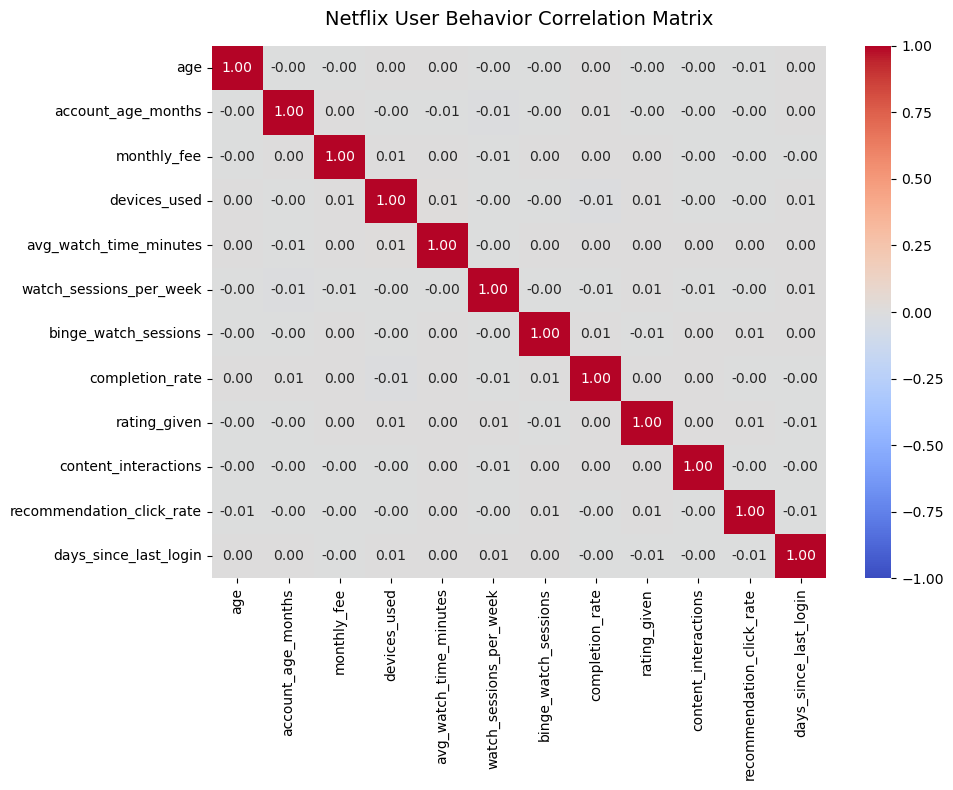

In [15]:
numeric_df = df.select_dtypes(include = ['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot= True, fmt = ".2f", cmap ="coolwarm", vmin = -1, vmax = 1)
plt.title("Netflix User Behavior Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
#plt.savefig("user_behavior_correlation.png")
#plt.close()
plt.show()

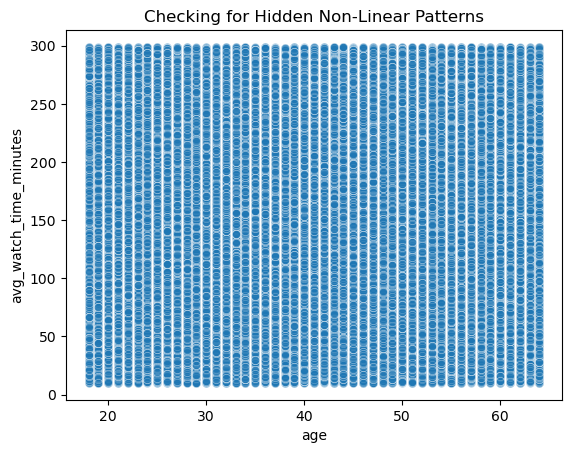

In [ ]:
# Check if there is a hidden, curved relationship between Age and Watch Time
sns.scatterplot(data=df, x='age', y='avg_watch_time_minutes', alpha=0.5)
plt.title("Checking for Hidden Non-Linear Patterns")
plt.show()

In [17]:
device_analysis = df.groupby('primary_device').agg(
    avg_binge_session = ('binge_watch_sessions', 'mean'),
    avg_completion_rate = ('completion_rate', 'mean'),
    avg_session_per_week = ('watch_sessions_per_week', 'mean')
).reset_index()
print("-- Device Engagement Analysis --")
print(device_analysis)

-- Device Engagement Analysis --
  primary_device  avg_binge_session  avg_completion_rate  avg_session_per_week
0         Laptop           7.038532            64.765929             10.001039
1         Mobile           7.031307            64.728327              9.958999
2       Smart TV           6.936873            64.224646              9.956297
3         Tablet           7.003483            64.413318             10.032242


In [18]:
genre_recommendation = df.groupby('favorite_genre').agg(
    mean_click_rate = ('recommendation_click_rate', 'mean'),
    mean_rating_given = ('rating_given', 'mean'),
    user_count = ('user_id', 'count')
).sort_values(by='mean_click_rate', ascending=False).reset_index()
print("\n-- Genre Recommendation Effectiveness --")
print(genre_recommendation)


-- Genre Recommendation Effectiveness --
  favorite_genre  mean_click_rate  mean_rating_given  user_count
0         Comedy        50.169516           3.017351        6259
1         Horror        50.005946           3.003455        6223
2         Action        49.849238           2.988099        6235
3       Thriller        49.799425           2.992488        6257
4    Documentary        49.594931           3.007887        6352
5          Drama        49.336289           3.018556        6203
6        Romance        49.089621           2.996816        6282
7         Sci-Fi        48.651802           2.993812        6189


In [23]:
churn_counts = df['churned'].value_counts()
churn_pct = df['churned'].value_counts(normalize = True)*100
print(f"Total Database Rows: {len(df)}")
print(f"Active Subscribers (No): {churn_counts['No']} ({churn_pct['No']:.2f}%)")
print(f"Churned Subscribers (Yes): {churn_counts['Yes']} ({churn_pct['Yes']:.2f}%)")

Total Database Rows: 50000
Active Subscribers (No): 40036 (80.07%)
Churned Subscribers (Yes): 9964 (19.93%)


In [27]:
regional_metrics = df.groupby('country').agg(
    total_users=('user_id', 'count'),
    avg_daily_minutes=('avg_watch_time_minutes', 'mean'),
    churn_rate_pct=('churned', lambda x: (x == 'Yes').mean() * 100),
    avg_monthly_revenue=('monthly_fee', 'mean')
).sort_values(by='churn_rate_pct', ascending=False)
print(regional_metrics.round(2))

           total_users  avg_daily_minutes  churn_rate_pct  avg_monthly_revenue
country                                                                       
Australia         5004             152.38           20.96                12.26
Japan             4907             153.63           20.81                12.34
India             5028             154.56           20.31                12.37
France            4919             155.63           20.21                12.29
UK                4929             155.33           19.90                12.28
Canada            4959             155.17           19.84                12.31
Brazil            5116             154.09           19.51                12.34
Spain             5027             156.71           19.28                12.36
Germany           5024             156.19           19.27                12.32
USA               5087             155.77           19.25                12.35


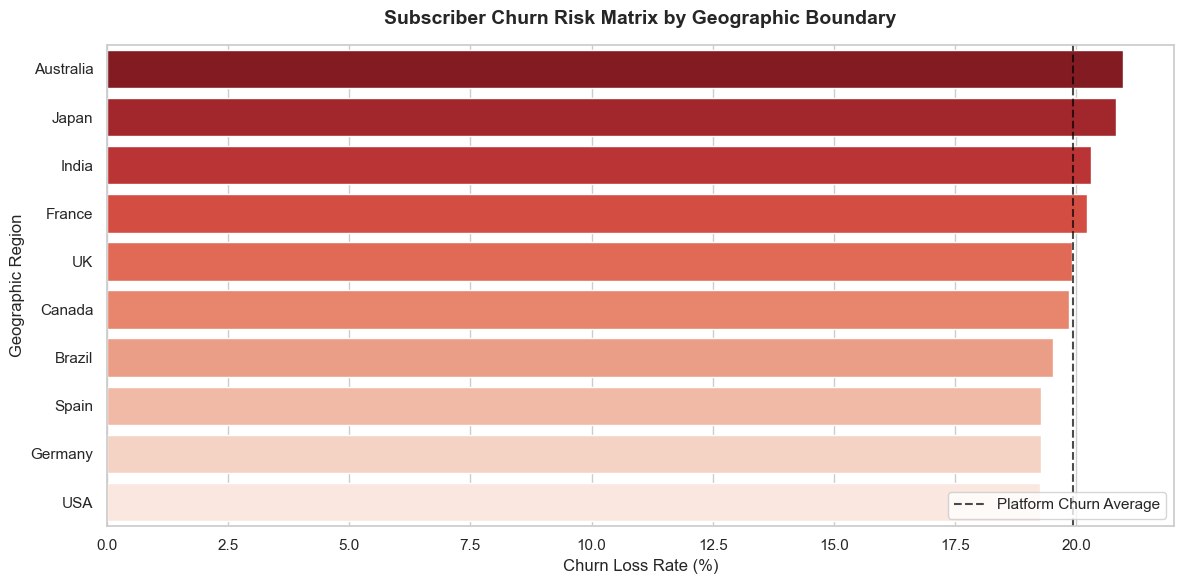

In [28]:
# Figure 1: Demographic Engagement Profiles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x='gender', hue='churned', palette='Set2', ax=axes[0])
axes[0].set_title('Churn Metric Balance Across Gender Personas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Subscriber Count')

sns.boxplot(data=df, x='churned', y='days_since_last_login', hue='churned', palette='coolwarm', ax=axes[1], legend=False)
axes[1].set_title('Inactivity Window (Days Since Last Login) vs Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Has Churned?')
axes[1].set_ylabel('Days Inactive')
plt.tight_layout()
plt.savefig('netflix_demographics_and_inactivity.png', dpi=300)
plt.close()

# Figure 2: Operational Risks (Country Risk Profiles)
plt.figure(figsize=(12, 6))
regional_metrics_sorted = regional_metrics.reset_index().sort_values(by='churn_rate_pct', ascending=False)
sns.barplot(data=regional_metrics_sorted, x='churn_rate_pct', y='country', hue='country', palette='Reds_r', legend=False)
plt.axvline(x=df['churned'].eq('Yes').mean()*100, color='black', linestyle='--', alpha=0.7, label='Platform Churn Average')
plt.title('Subscriber Churn Risk Matrix by Geographic Boundary', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Churn Loss Rate (%)')
plt.ylabel('Geographic Region')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

